In [1]:
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

import sys
my_path = "../../Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from tools import *
from fit_funcs import *
from entropy import *
import costfun.costfun as cost
import utils.figures as fig_help
from RandomMatrixTheory import goe
import utils.tools as tools

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'cm'
# plt.rcParams["mathtext.fontset"] = "cm"
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}

%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

linestyle_ls = ['-','--',':', '-.']
linestyle = itertools.cycle(linestyle_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   
from scipy import stats

# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import erf
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import lambertw
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
from scipy.interpolate import UnivariateSpline as InterpolateSpline
from scipy.interpolate import splrep, splev
from scipy.interpolate import make_interp_spline as make_spline
from scipy.interpolate import interp1d
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import fsolve

from mpl_toolkits.axes_grid1 import make_axes_locatable

# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists

base_dir = "../results/"

print(base_dir[2:])
%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}


/Users/rafal.swietek/Projects/CODES/QHamSolver/QuadQSun/Jupter_Python
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../Python/
/results/


## TESTS

[0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15]
../results/DIAGONALIZATION/realisation=0/_L=1000,N=100,J=1,g=1,zeta=0.2,alfa=0.05,h=0,w=2.hdf5
../results/DIAGONALIZATION/realisation=1/_L=1000,N=100,J=1,g=1,zeta=0.2,alfa=0.05,h=0,w=2.hdf5
../results/DIAGONALIZATION/realisation=2/_L=1000,N=100,J=1,g=1,zeta=0.2,alfa=0.05,h=0,w=2.hdf5
../results/DIAGONALIZATION/realisation=3/_L=1000,N=100,J=1,g=1,zeta=0.2,alfa=0.05,h=0,w=2.hdf5
../results/DIAGONALIZATION/realisation=4/_L=1000,N=100,J=1,g=1,zeta=0.2,alfa=0.05,h=0,w=2.hdf5
../results/DIAGONALIZATION/realisation=5/_L=1000,N=100,J=1,g=1,zeta=0.2,alfa=0.05,h=0,w=2.hdf5
../results/DIAGONALIZATION/realisation=6/_L=1000,N=100,J=1,g=1,zeta=0.2,alfa=0.05,h=0,w=2.hdf5
../results/DIAGONALIZATION/realisation=7/_L=1000,N=100,J=1,g=1,zeta=0.2,alfa=0.05,h=0,w=2.hdf5
../results/DIAGONALIZATION/realisation=8/_L=1000,N=100,J=1,g=1,zeta=0.2,alfa=0.05,h=0,w=2.hdf5
../results/DIAGONALIZATION/r

ZeroDivisionError: division by zero

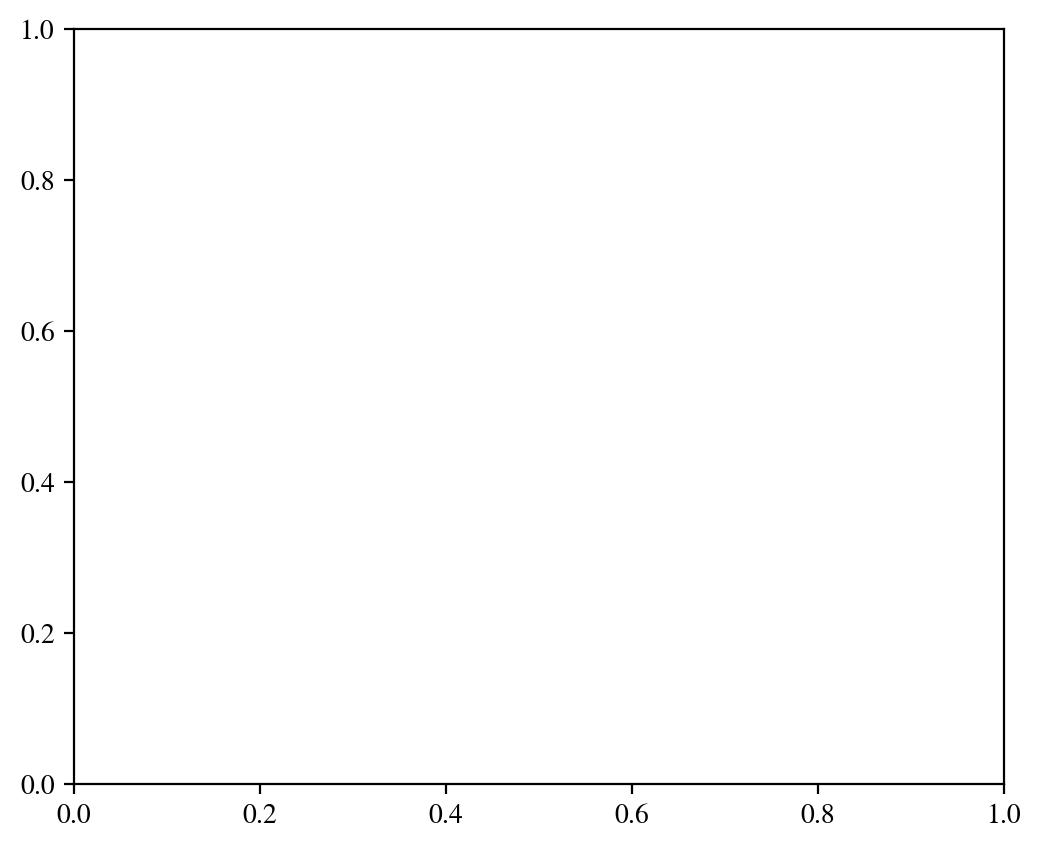

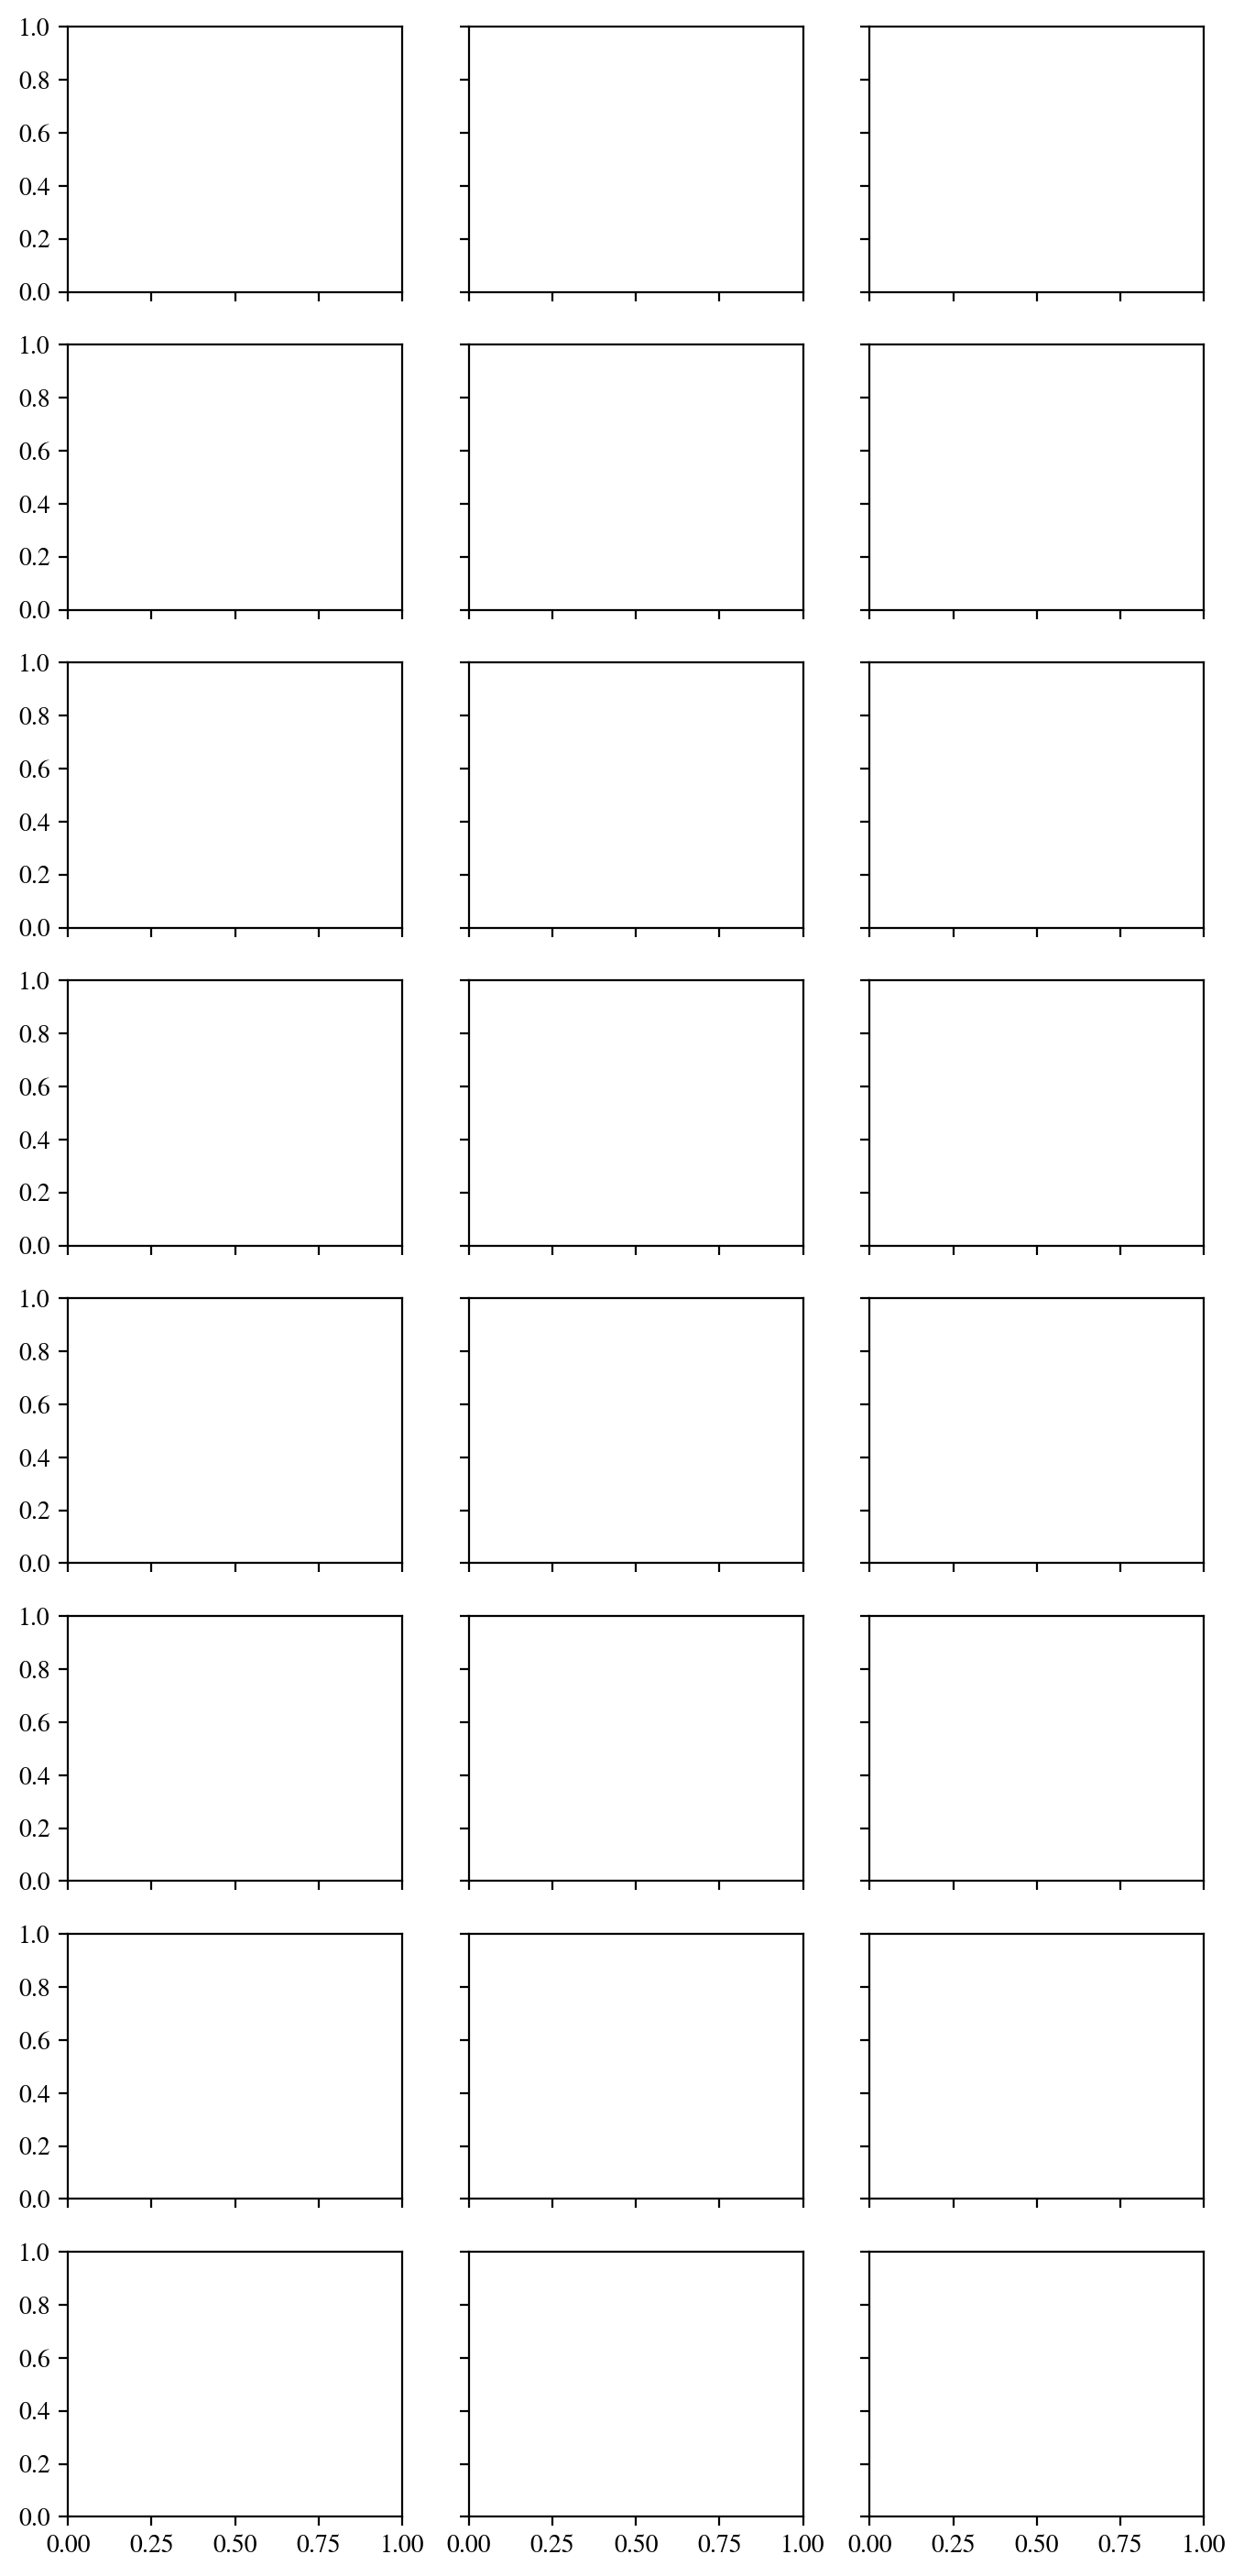

In [2]:
markers = itertools.cycle(markers_ls)

L_total=2600

J=1
alfa=1.0
h=0.0
w=2.
zeta=0.2

N=100
gamma=1
ini_ave=0
L = L_total - N
scaled_disorder = 0

alfa_crit = 0.745
window=4
projected = 0

alfa_vals = np.arange(0.05, 1.2, 0.05)
print(alfa_vals)

# alfa_vals = [1, 6, 16, 26, 36, 46]

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(6,5), dpi = 200)
figDOS, axDOS = plt.subplots( nrows=8, ncols=3, figsize=(8,18), dpi = 200, sharey = 'row', sharex = True)
axDOS = axDOS.flatten()

sizes = np.array( [1000, 2000, 4000, 8000, 10000, 16000, 20000, 24000] )

# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm= matplotlib.colors.Normalize(vmin=min(sizes), vmax=max(sizes) ))
s_m.set_array([])

for L in sizes:
    col = s_m.to_rgba(L)
    
    gap_ratio = []
    for iia, alfa in enumerate( alfa_vals ):
        r = 0
        counter = 0
        energies = []
        for real in range(15):
            name = base_dir + 'DIAGONALIZATION/realisation=%d/'%real + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
            if exists(name):
                with h5py.File(name, "r") as file:
                    E = np.array(file.get('eigenvalues'))[0]
                    energies.append(E)
                    _, indices, counts = np.unique(np.round(E, 14), return_index=True, return_counts=True)
                    if (indices[counts > 1]).size > 0:
                        print(indices[counts > 1])
                    
                    dim = E.size
                    gaps = np.diff(E)
                    ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
                    print(L, np.mean(ratio_tmp[dim//2 - 200 : dim//2 + 200]))
                    # r += np.mean(ratio_tmp[dim//4 : dim//4*3])
                    r += np.mean( ratio_tmp[dim//2 - 200 : dim//2 + 200] )
                    counter += 1
            else:
                print(name)
        gap_ratio.append( r / counter)
        print(L, alfa, r / counter)
        hist, bins = np.histogram( np.array(energies).flatten(), bins = 50, normed=True)
        axDOS[iia].stairs(hist, bins, color = col)
    axis.scatter(alfa_vals, gap_ratio, color = col)   
    
ylab = r"$\langle r\rangle$"
fig_help.set_plot_elements(axis, ylabel=ylab, xlabel=r"$\alpha$", font_size=16, set_legend=False, xscale='linear', yscale='linear')

for iia, alfa in enumerate( alfa_vals ):
    fig_help.set_plot_elements(axDOS[iia], ylabel=r"$\rho(E)$" if iia%3 == 0 else "", xlabel=r"$E$" if iia>5 else "", font_size=16, set_legend=False, xscale='linear', yscale='linear')
    
fig.subplots_adjust(top=0.92)
cbar_ax = fig.add_axes([0.15, 0.95, 0.7, 0.04])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'horizontal')
cbar.set_label(r"$\alpha$", fontsize=16)
cbar_ax.xaxis.set_ticks_position('top')
cbar_ax.xaxis.set_label_position('top')


fig.subplots_adjust(wspace = 0.23, hspace=0.13)
figDOS.subplots_adjust(wspace = 0.02, hspace=0.02)

## GAP RATIO

### MOBILITY EDGE

[0.04 0.08 0.12 0.16 0.2  0.24 0.28 0.32 0.36 0.4  0.44 0.48 0.52 0.56
 0.6  0.64 0.68 0.72 0.76 0.8  0.84 0.88 0.92 0.96 1.  ]


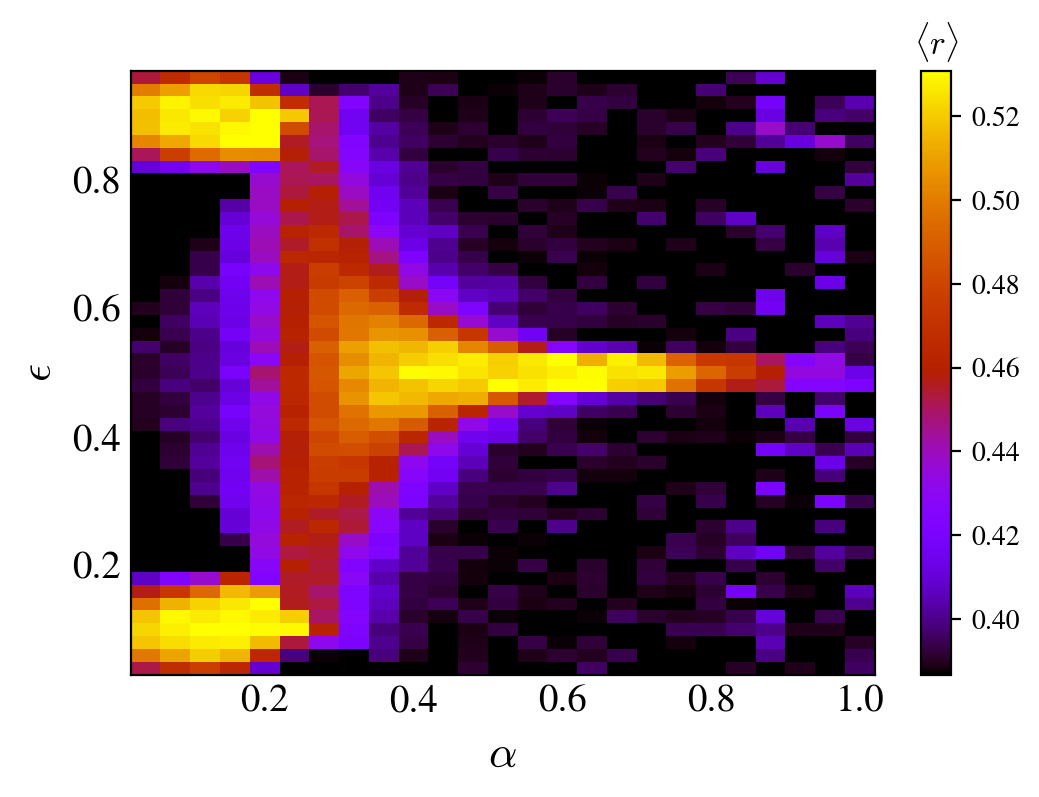

In [4]:

markers = itertools.cycle(markers_ls)

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(6,4), dpi = 200)

J=1

alfa=0.6
h=0
w=1
zeta=0.1

N=500
gamma=1
ini_ave=0

L = 32000
N = 1000
# N = L//4

alfa_vals = np.arange(0.04, 1.01, 0.04)
print(alfa_vals)
    
window = 6
projected = 1

energy_density = None
gap_ratio_density = []
for ii, alfa in enumerate(alfa_vals):
    name = base_dir + 'DIAGONALIZATION/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
    if exists(name):
        with h5py.File(name, "r") as file:
            E = np.array(file.get('mean energies'))[1 : -1]
            energy_density = np.array(file.get('energy_density'))[1:-1]
            # E = E[1:-1]
            # gap_ratio = np.array(file.get('gap_ratio_density'))#[1:-1]
            # gap_ratio = (gap_ratio - 0.3867) / (0.5307 - 0.3867)
            
            all_gap_ratios = np.array(file.get('gap ratio'))
            dimm = all_gap_ratios.size
            gap_ratio = np.zeros(energy_density.shape)
            for iie, eps in enumerate(energy_density):
                E_target = (E[-1] - E[0]) * eps + E[0]
                idx = np.argmin( np.abs(E - E_target ))
                gap_ratio[iie] = np.mean( all_gap_ratios[ np.max([idx - 5,0]) : np.min([idx + 5, dimm])] )
            
            gap_ratio_density.append(gap_ratio)
    else:
        print(name)

energy_density = np.array(energy_density)
gap_ratio_density = np.array(gap_ratio_density)

interaction = np.array([alfa_vals for _ in energy_density])

#white = plt.get_cmap('seismic', 100)(0.5*np.ones(1))
upper = plt.get_cmap('gnuplot', 100)(np.linspace(0.0, 1.0, 100))
colors = np.vstack((upper))  

mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

X, Y = np.meshgrid(alfa_vals, energy_density)

p = axis.pcolormesh(X, Y, np.transpose(gap_ratio_density), shading='nearest', cmap=mymap, vmin=0.3867, vmax=0.5309)
fig_help.set_plot_elements(axis, ylabel=r"$\epsilon$", xlabel=r"$\alpha$", font_size=14, set_legend=False)
# axis.set_title(r"$L=%d, N=%d, g_0=%.2f$"%(L, N, J), fontsize=16)
clb = fig.colorbar(p)
clb.ax.set_title(r"$\langle r\rangle$")

fig.subplots_adjust(wspace = 0.02, hspace=0.02)
# fig.savefig("plots_AGP/FigS2.pdf", bbox_inches = 'tight', pad_inches=0.02)

[0.04 0.08 0.12 0.16 0.2  0.24 0.28 0.32 0.36 0.4  0.44 0.48 0.52 0.56
 0.6  0.64 0.68 0.72 0.76 0.8  0.84 0.88 0.92 0.96 1.   1.04 1.08 1.12
 1.16 1.2 ]
[0.04 0.08 0.12 0.16 0.2  0.24 0.28 0.32 0.36 0.4  0.44 0.48 0.52 0.56
 0.6  0.64 0.68 0.72 0.76 0.8  0.84 0.88 0.92 0.96 1.   1.04 1.08 1.12
 1.16 1.2 ]
../results/DIAGONALIZATION/_L=32000,N=1000,J=1,g=1,zeta=0.1,alfa=1.04,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=32000,N=1000,J=1,g=1,zeta=0.1,alfa=1.08,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=32000,N=1000,J=1,g=1,zeta=0.1,alfa=1.12,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=32000,N=1000,J=1,g=1,zeta=0.1,alfa=1.16,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=32000,N=1000,J=1,g=1,zeta=0.1,alfa=1.2,h=0,w=1.hdf5
[0.04 0.08 0.12 0.16 0.2  0.24 0.28 0.32 0.36 0.4  0.44 0.48 0.52 0.56
 0.6  0.64 0.68 0.72 0.76 0.8  0.84 0.88 0.92 0.96 1.   1.04 1.08 1.12
 1.16 1.2 ]
../results/DIAGONALIZATION/_L=40000,N=1000,J=1,g=1,zeta=0.1,alfa=0.44,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=40000,N=100

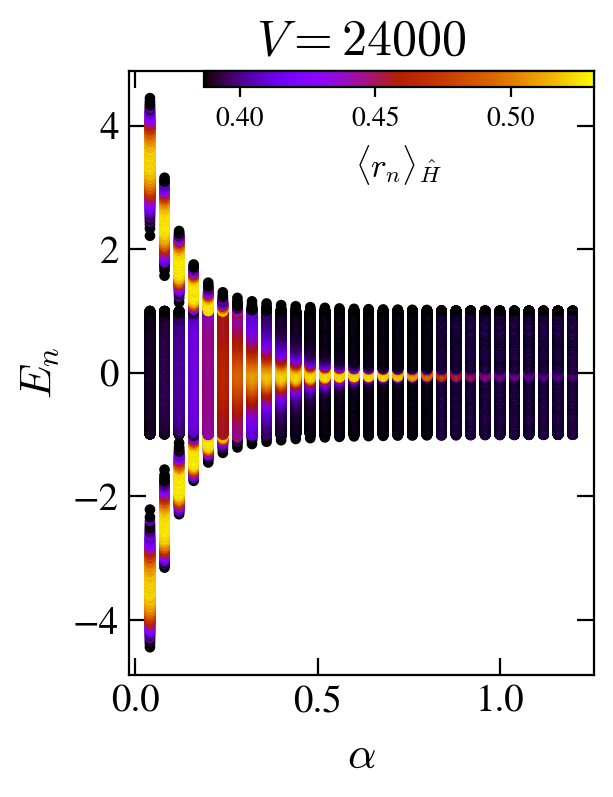

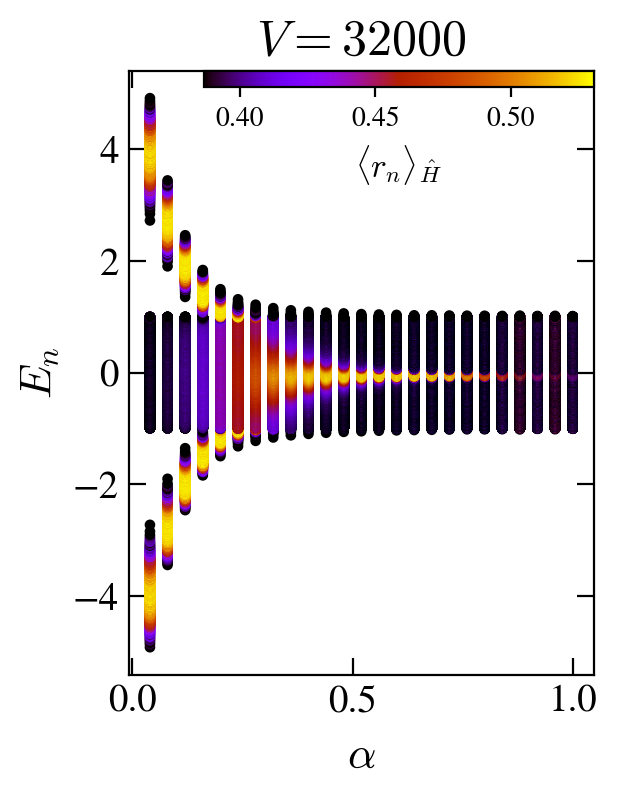

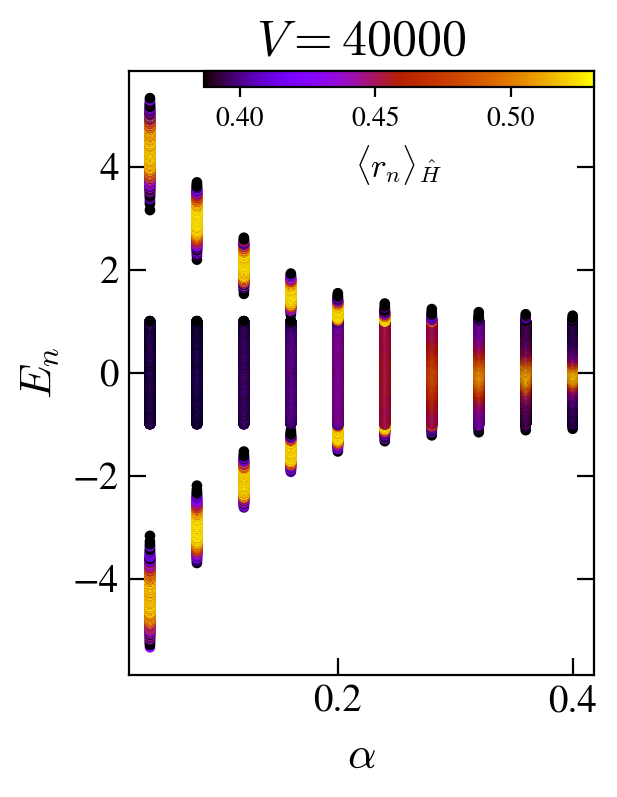

In [27]:

markers = itertools.cycle(markers_ls)


J=1

alfa=0.6
h=0

w=1
zeta=0.1

N=100
gamma=1
ini_ave=0

L = 10000
N = 1000#L//4

sizes = np.array( [1000, 2000, 4000, 8000, 10000, 16000, 20000] )
sizes = np.array( [24000, 32000, 40000] )

for L in sizes:
    
    fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(3,4), dpi = 200)
    alfa_vals = np.arange(0.04, 1.21, 0.04)
    print(alfa_vals)
        
    window = 6
    projected = 1

    s_m = matplotlib.cm.ScalarMappable(cmap='gnuplot', norm= matplotlib.colors.Normalize(vmin=0.3867, vmax=0.5307 ))
    s_m.set_array([])

    dim = L+N
    for ii, alfa in enumerate(alfa_vals):
        name = base_dir + 'DIAGONALIZATION/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
        if exists(name):
            with h5py.File(name, "r") as file:
                E = np.array(file.get('mean energies'))[1 : -1]
                gap_ratio = np.array(file.get('gap ratio'))
                # E = E[::10]
                # gap_ratio = gap_ratio[::10]
                
                # idx = np.argmin( np.abs(E - np.mean(E) ))
                # idx = 200
                # E = E[idx - 200 : idx + 200]
                # gap_ratio = gap_ratio[idx - 200 : idx + 200]
                
                colors = [s_m.to_rgba(r) for r in gap_ratio]
                
                axis.scatter(np.ones(E.size) * alfa, E, color=colors, s=8)
        else:
            print(name)

    fig_help.set_plot_elements(axis, ylabel=r"$E_n$", xlabel=r"$\alpha$", font_size=14, set_legend=False)

    # fig.subplots_adjust(right=0.96)
    cbar_ax = fig.add_axes([0.25, 0.86, 0.65, 0.02])
    # fig.colorbar(im, cax=cbar_ax)
    cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'horizontal')
    cbar.set_label(r"$\langle r_n\rangle_{\hat{H}}$", fontsize=12)
    cbar_ax.xaxis.set_ticks_position('bottom')
    cbar_ax.xaxis.set_label_position('bottom')

    fig.subplots_adjust(wspace = 0.02, hspace=0.02)
    axis.set_title(r"$V=%d$"%L, fontsize=18)
    fig.savefig("Fig_V=%d.pdf"%L, bbox_inches = 'tight', pad_inches=0.02)

[0.02 0.04 0.06 0.08 0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26 0.28
 0.3  0.32 0.34 0.36 0.38 0.4  0.42 0.44 0.46 0.48 0.5  0.52 0.54 0.56
 0.58 0.6  0.62 0.64 0.66 0.68 0.7  0.72 0.74 0.76 0.78 0.8  0.82 0.84
 0.86 0.88 0.9  0.92 0.94 0.96 0.98 1.   1.02 1.04 1.06 1.08 1.1  1.12
 1.14 1.16 1.18 1.2 ]


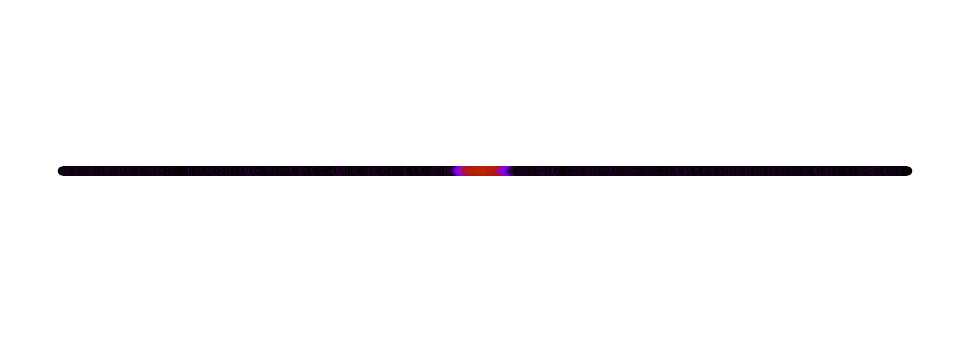

In [31]:

markers = itertools.cycle(markers_ls)


J=1

alfa=0.6
h=0

w=1
zeta=0.1

N=100
gamma=1
ini_ave=0

L = 10000
N = 1000#L//4

sizes = np.array( [8000] )

import matplotlib.animation as animation
from matplotlib.animation import PillowWriter

for L in sizes:
    
    
    alfa_vals = np.arange(0.02, 1.21, 0.02)
    print(alfa_vals)
        
    window = 6
    projected = 1

    s_m = matplotlib.cm.ScalarMappable(cmap='gnuplot', norm= matplotlib.colors.Normalize(vmin=0.3867, vmax=0.5307 ))
    s_m.set_array([])

    dim = L+N
    ims = []

    fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(6,2), dpi = 200)
    for ii, alfa in enumerate(alfa_vals):
        axis.axis('off')
        name = base_dir + 'DIAGONALIZATION/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
        if exists(name):
            with h5py.File(name, "r") as file:
                E = np.array(file.get('mean energies'))[1 : -1]
                gap_ratio = np.array(file.get('gap ratio'))
                
                colors = [s_m.to_rgba(r) for r in gap_ratio]
                im = axis.scatter((E - E[0]) / (E[-1] - E[0]) , np.zeros(E.size), color=colors, s=5)
                ims.append( [im] )
        else:
            print(name)
    
    ani = animation.ArtistAnimation(fig, ims, interval=20000, blit=True)#, repeat_delay=int(1e5))
    writer = PillowWriter(fps=2000)
    ani.save("demo2.gif", writer=writer)

    plt.show()
    # fig_help.set_plot_elements(axis, ylabel=r"$E_n$", xlabel=r"$\alpha$", font_size=14, set_legend=False)
    
    # fig.subplots_adjust(right=0.96)
    # cbar_ax = fig.add_axes([0.25, 0.2, 0.65, 0.02])
    # # fig.colorbar(im, cax=cbar_ax)
    # cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'horizontal')
    # cbar.set_label(r"$\langle r_n\rangle_{\hat{H}}$", fontsize=12)
    # cbar_ax.xaxis.set_ticks_position('top')
    # cbar_ax.xaxis.set_label_position('top')

    fig.subplots_adjust(wspace = 0.02, hspace=0.02)
    # axis.set_title(r"$V=%d$"%L, fontsize=18)

In [39]:
print( 0.8**(7.2) / 0.8**(7))
print( 6.8**0.8 / 7**0.8, 7**0.8 / 7.2**0.8)

0.956352499790037
0.9770767927174313 0.9777153528430895


### FINITE SIZE SCALING

[0.05 0.15 0.5  0.9 ]


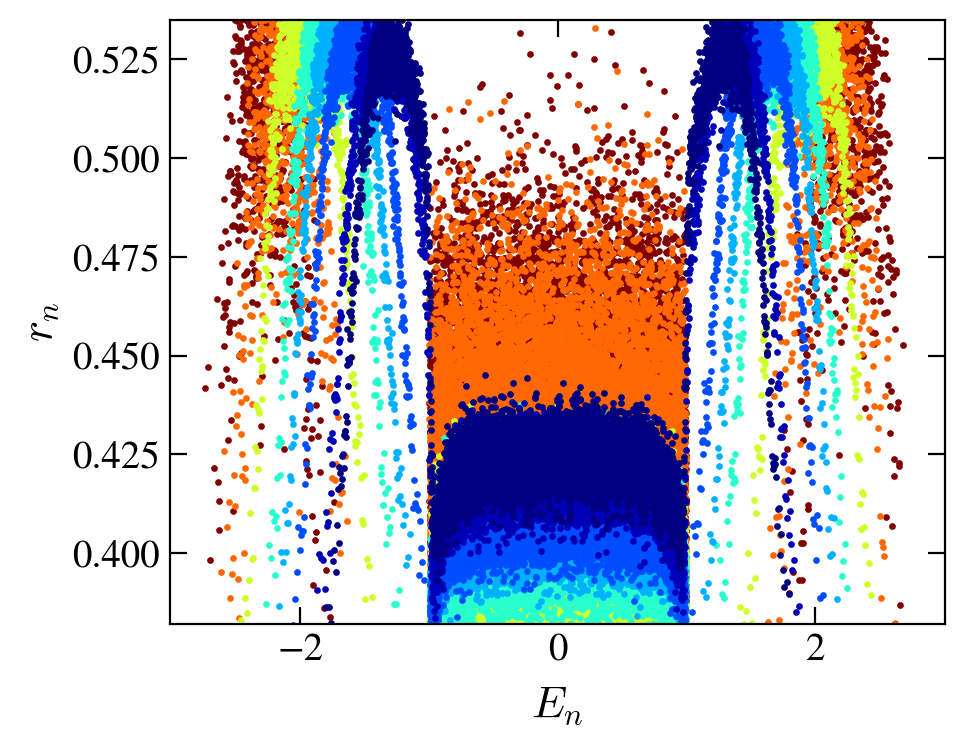

In [ ]:
markers = itertools.cycle(markers_ls)

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,4), dpi = 200)

J=1

alfa=0.12
h=0
w=1
zeta=0.1

N=500
gamma=1
ini_ave=0

L = 20000

alfa_vals = np.array( [0.05, 0.15, 0.5, 0.9] )
print(alfa_vals)

sizes = np.array( [8000, 10000, 16000, 20000, 24000, 32000, 40000, 48000] )
window = 10
_smooth = 0

s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm= matplotlib.colors.Normalize(vmin=min(sizes), vmax=max(sizes) ))
s_m.set_array([])

for L in sizes:
    dim = L+N
    N = 1000
    # N = L//4
    
    col = s_m.to_rgba(L)
    name = base_dir + 'DIAGONALIZATION/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
    if exists(name):
        with h5py.File(name, "r") as file:
            E = np.array(file.get('mean energies'))[1 : -1]
            gap_ratio = np.array(file.get('gap ratio'))
            
            if _smooth:
                E = E[window//2 : -window//2]
                gap_ratio = tools.remove_fluctuations(gap_ratio, bucket_size=window)[window//2 : -window//2]
            axis.scatter(E, gap_ratio, color=col, s=2)
    else:
        print(name)

fig_help.set_plot_elements(axis, ylabel=r"$r_n$", xlabel=r"$E_n$", font_size=14, set_legend=False, ylim=(0.382, 0.535))


fig.subplots_adjust(wspace = 0.02, hspace=0.02)
# fig.savefig("plots_AGP/FigS2.pdf", bbox_inches = 'tight', pad_inches=0.02)

[0.02 0.04 0.06 0.08 0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26 0.28
 0.3  0.32 0.34 0.36 0.38 0.4  0.42 0.44 0.46 0.48 0.5  0.52 0.54 0.56
 0.58 0.6  0.62 0.64 0.66 0.68 0.7  0.72 0.74 0.76 0.78 0.8  0.82 0.84
 0.86 0.88 0.9  0.92 0.94 0.96 0.98 1.   1.02 1.04 1.06 1.08 1.1  1.12
 1.14 1.16 1.18 1.2 ]
../results/DIAGONALIZATION/_L=24000,N=1000,J=1,g=1,zeta=0.1,alfa=0.02,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=24000,N=1000,J=1,g=1,zeta=0.1,alfa=0.06,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=24000,N=1000,J=1,g=1,zeta=0.1,alfa=0.1,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=24000,N=1000,J=1,g=1,zeta=0.1,alfa=0.14,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=24000,N=1000,J=1,g=1,zeta=0.1,alfa=0.18,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=24000,N=1000,J=1,g=1,zeta=0.1,alfa=0.22,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=24000,N=1000,J=1,g=1,zeta=0.1,alfa=0.26,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=24000,N=1000,J=1,g=1,zeta=0.1,alfa=0.3,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=24

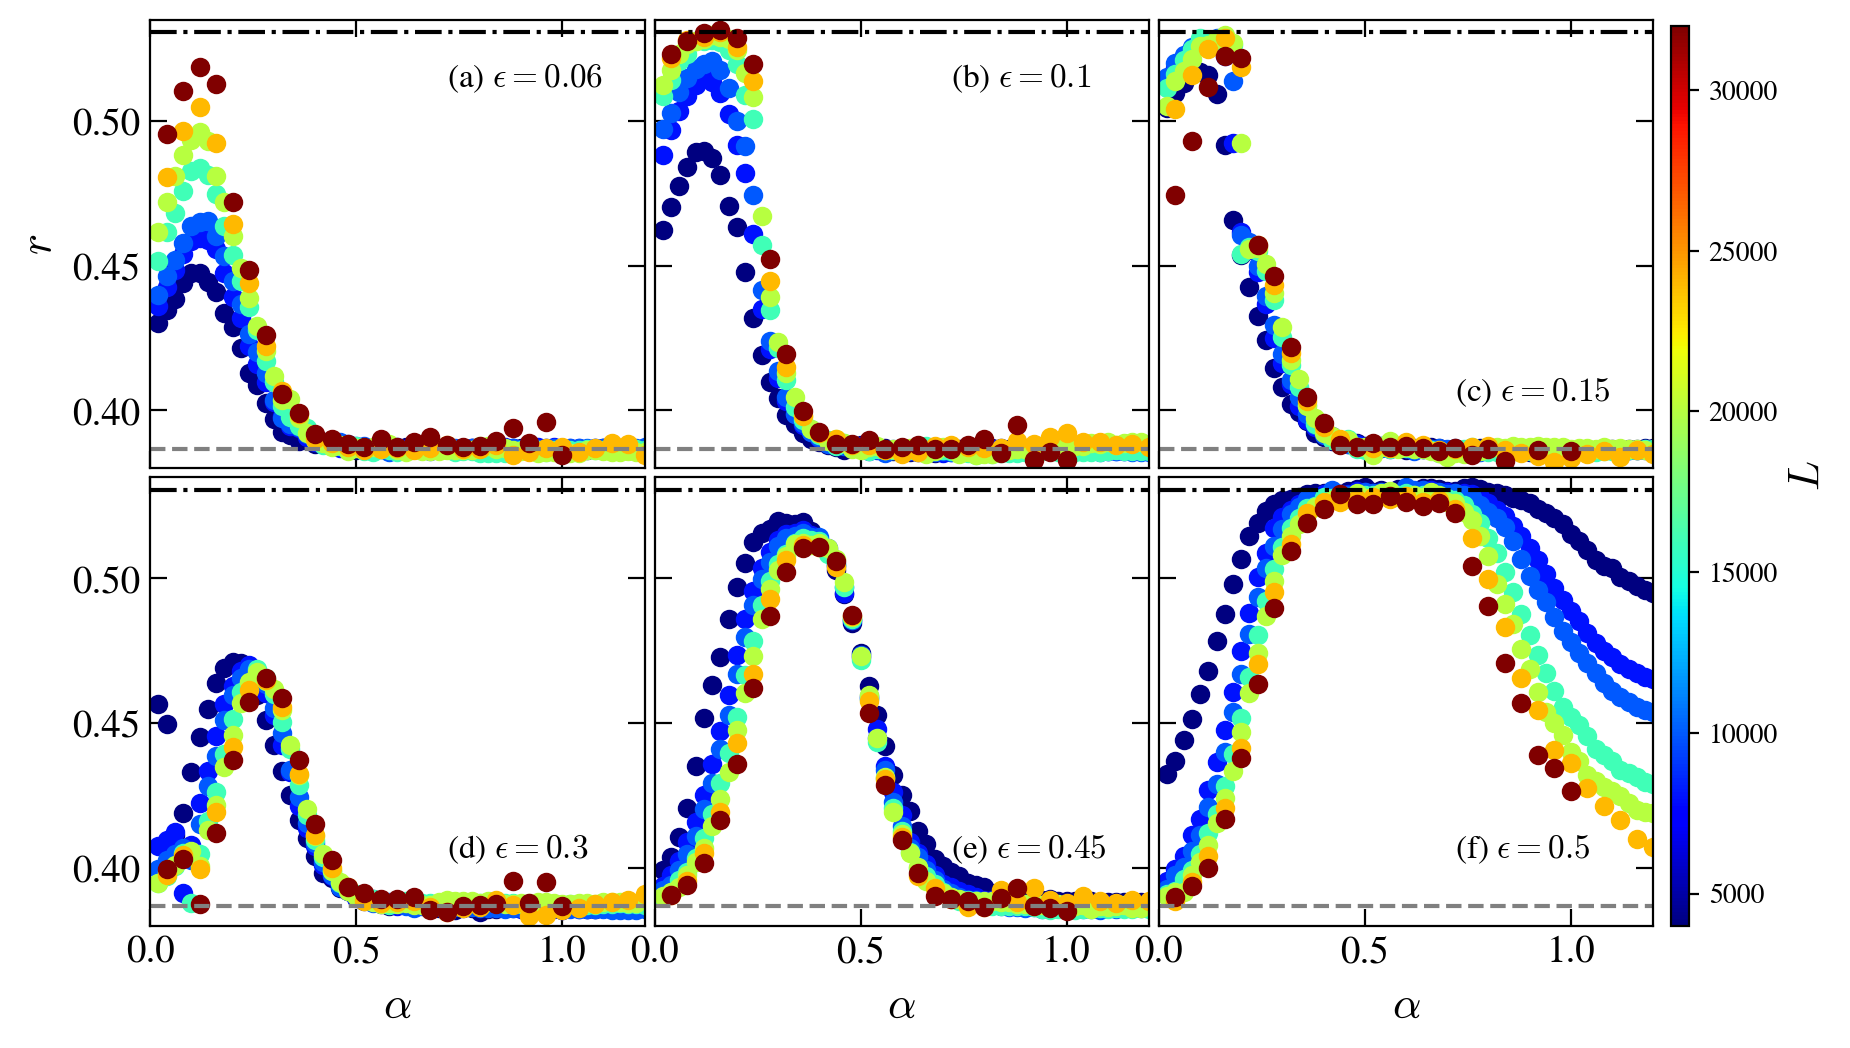

In [10]:

markers = itertools.cycle(markers_ls)

J=1

alfa=0.6
h=0
w=1
zeta=0.1

N=500
gamma=1
ini_ave=0

L = 4000

alfa_vals = np.arange(0.02, 1.21, 0.02)
print(alfa_vals)
    
window = 6
projected = 1

energy_density = None
gap_ratio_density = []

sizes = np.array( [4000, 8000, 10000, 16000, 20000, 24000, 32000] )

# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm= matplotlib.colors.Normalize(vmin=min(sizes), vmax=max(sizes))) 
s_m.set_array([])

epsilons = [0.06, 0.1, 0.15, 0.3, 0.45, 0.5]
fig, axis = plt.subplots( nrows=2, ncols=3, figsize=(9,6), dpi = 200, sharey = True, sharex = True)
axis = axis.flatten()
labs = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]

for L in sizes:
    col = s_m.to_rgba(L)
    N = 1000#L//4
    
    gap_ratio = np.zeros( (6, alfa_vals.size) ); gap_ratio.fill(np.nan)
    for ii, alfa in enumerate(alfa_vals):
        name = base_dir + 'DIAGONALIZATION/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
        if exists(name):
            with h5py.File(name, "r") as file:
                E = np.array(file.get('mean energies'))[1 : -1]
                all_gap_ratios = np.array(file.get('gap ratio'))
                for iie, eps in enumerate(epsilons):
                    # idx = np.argmin( np.abs(E - eps) )
                    # gap_ratio[iie, ii] = np.array(file.get('gap_ratio_density2'))[idx]
                    E_target = (E[-1] - E[0]) * eps + E[0]
                    idx = np.argmin( np.abs(E - E_target ))
                    gap_ratio[iie, ii] = np.mean( all_gap_ratios[ max([idx - 50, 0]) : min([idx + 50, E.size])] )
        else:
            print(name)

    for iie, eps in enumerate(epsilons):
        axis[iie].scatter(alfa_vals, gap_ratio[iie], color=col)

for iie, eps in enumerate(epsilons):    
    fig_help.set_plot_elements(axis[iie], ylabel=r"$r$" if iie == 0 else "", xlabel=r"$\alpha$", font_size=14, set_legend=False, xlim = (0, 1.49), ylim=(0.38, 0.535))
    axis[iie].annotate(labs[iie] + r" $\epsilon=%g$"%eps, fontsize=12, xy=(0.6, 0.85) if iie < 2 else (0.6, 0.15), xycoords='axes fraction')
    axis[iie].set_xlim(0, 1.2)
    axis[iie].set_ylim(0.38, 0.535)
    axis[iie].axhline(y=0.3867, ls='--', color='gray')
    axis[iie].axhline(y=0.5307, ls='-.', color='k')

fig.subplots_adjust(right=0.96)
cbar_ax = fig.add_axes([0.97, 0.125, 0.01, 0.75])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$L$", fontsize=16)
# cbar_ax.xaxis.set_ticks_position('top')
# cbar_ax.xaxis.set_label_position('top')

fig.subplots_adjust(wspace = 0.02, hspace=0.02)
# fig.savefig("plots_AGP/FigS2.pdf", bbox_inches = 'tight', pad_inches=0.02)

In [58]:
(48/20)**2 * 10

57.599999999999994

In [55]:
14**4

38416

### DENSITY OF STATES

[0.04 0.12 0.2  0.28 0.36 0.44 0.52 0.6  0.68]
../results/DIAGONALIZATION/_L=40000,N=1000,J=1,g=1,zeta=0.1,alfa=0.44,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=40000,N=1000,J=1,g=1,zeta=0.1,alfa=0.52,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=40000,N=1000,J=1,g=1,zeta=0.1,alfa=0.6,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=40000,N=1000,J=1,g=1,zeta=0.1,alfa=0.68,h=0,w=1.hdf5


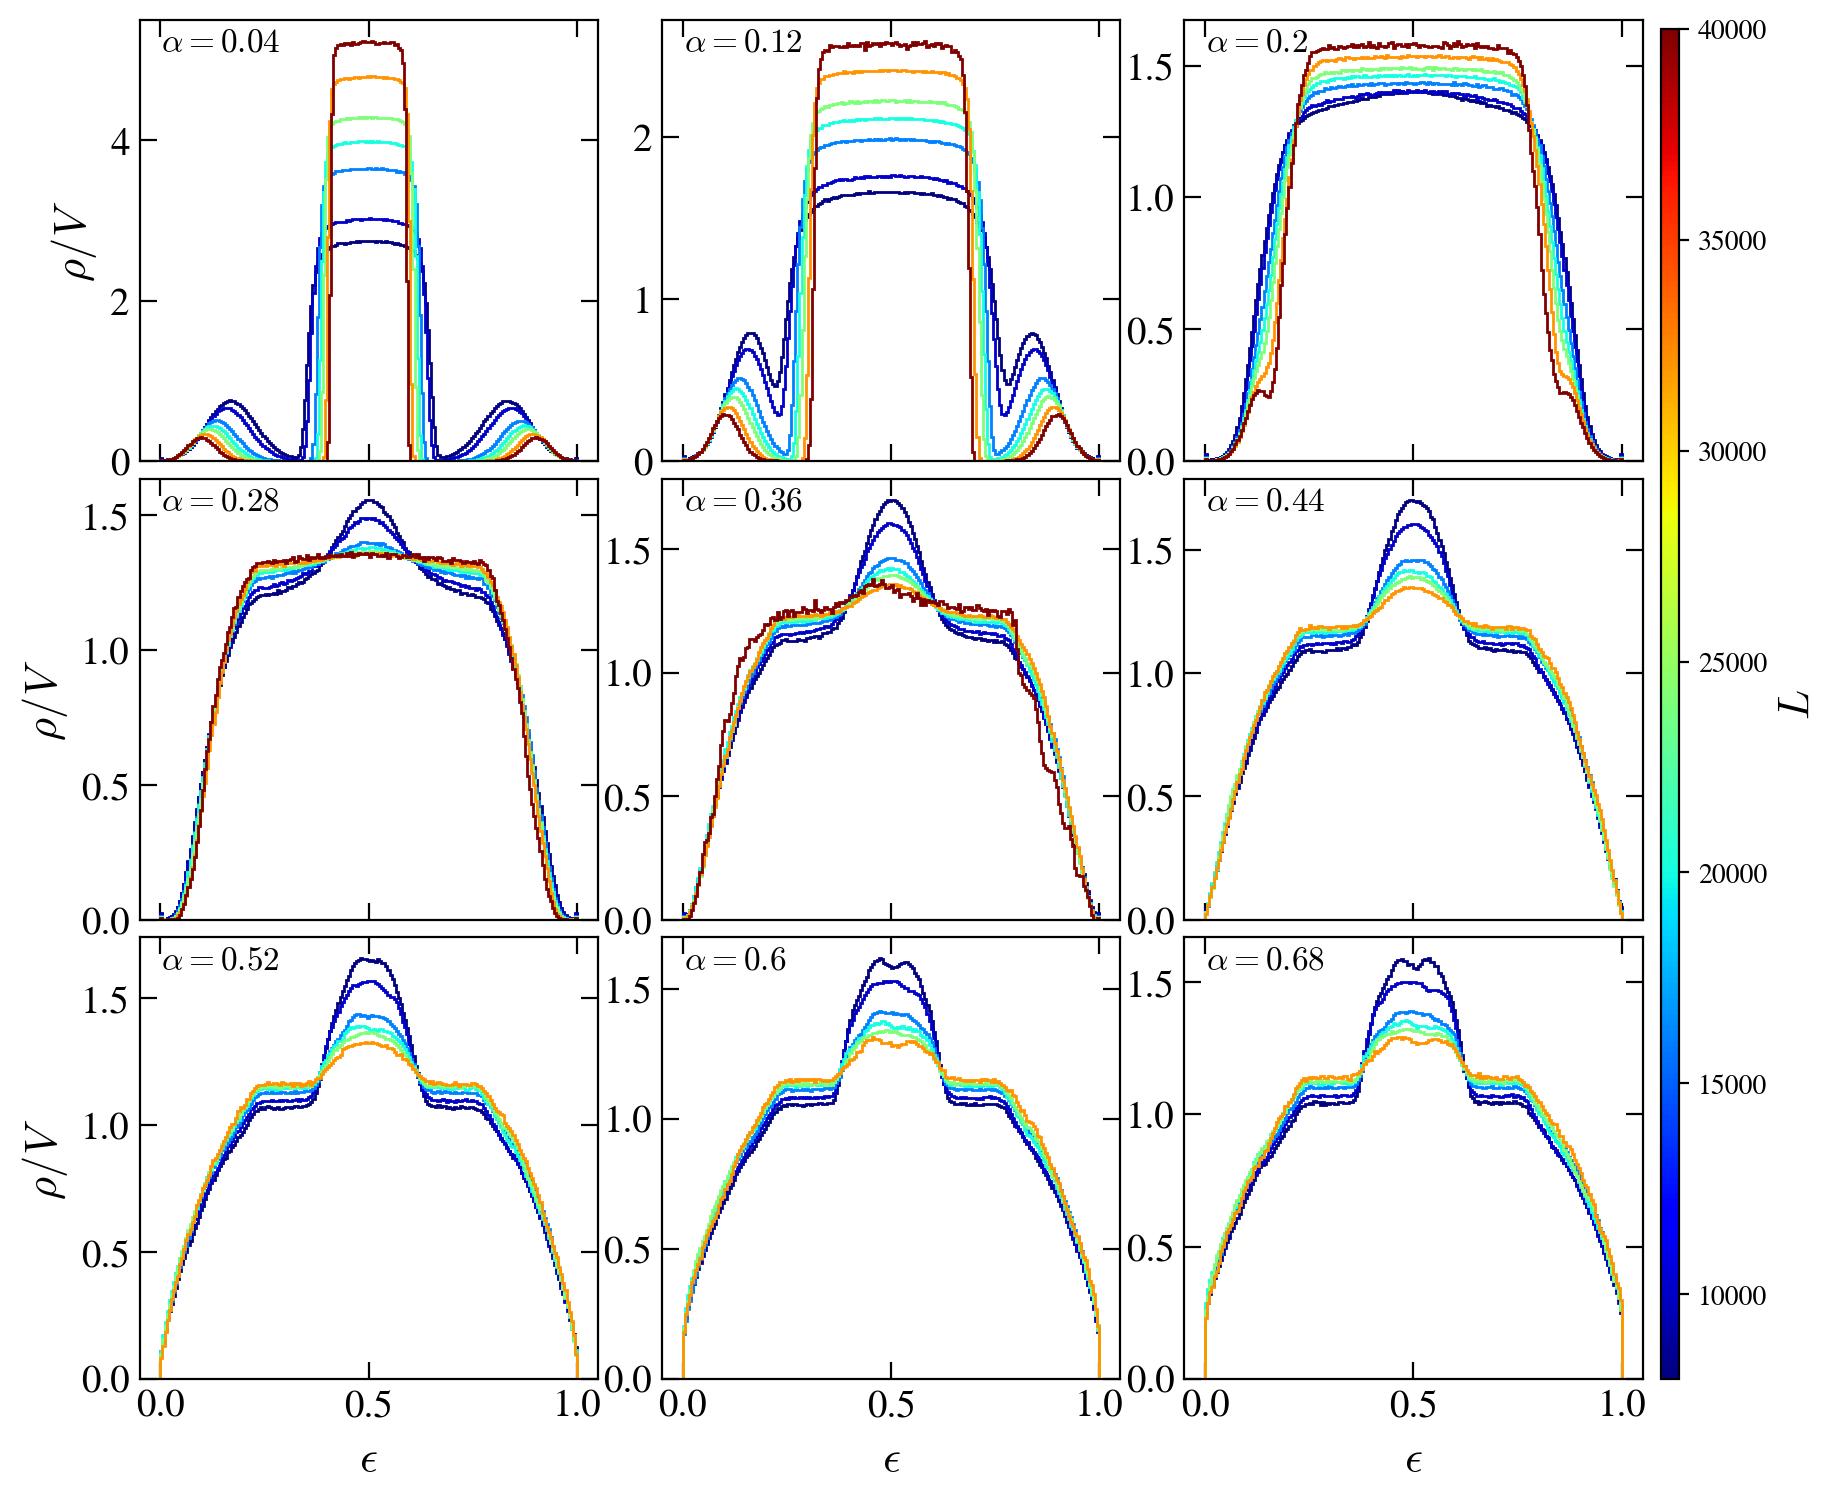

In [16]:

markers = itertools.cycle(markers_ls)

J=1

alfa=0.6
h=0
w=1
zeta=0.1

N=500
gamma=1
ini_ave=0

L = 4000
N = 1000#L//4

alfa_vals = np.arange(0.04, 0.7, 0.08)
# alfa_vals = np.array( [0.05, 0.15, 0.25, 0.4, 0.5, 0.6, 0.8, 1.0, 1.2] )
print(alfa_vals)
    
window = 6
projected = 1

energy_density = None
gap_ratio_density = []

sizes = np.array( [8000, 10000, 16000, 20000, 24000, 32000, 40000] )

# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm= matplotlib.colors.Normalize(vmin=min(sizes), vmax=max(sizes) ))
s_m.set_array([])

fig, axis = plt.subplots( nrows=3, ncols=3, figsize=(9,9), dpi = 200, sharex = True)
axis = axis.flatten()

for ii, alfa in enumerate(alfa_vals):
    for L in sizes:
        N = L//4
        N=1000
        col = s_m.to_rgba(L)
        name = base_dir + 'DIAGONALIZATION/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
        if exists(name):
            with h5py.File(name, "r") as file:
                E = np.array(file.get('energy_density'))
                db = E[1] - E[0]
                bins = np.array([E[0] - db/2, *(E + db/2)])
                DOS = np.array(file.get('DOS')) / (L+N)
                bins = np.array(file.get('bins'))
                
                axis[ii].stairs(DOS, bins, color=col)
        else:
            print(name)

    fig_help.set_plot_elements(axis[ii], ylabel=r"$\rho/V$" if ii %3== 0 else "", xlabel=r"$\epsilon$" if ii > 5 else "", font_size=14, set_legend=False, yscale='linear')
    axis[ii].annotate(r" $\alpha=%g$"%alfa, fontsize=12, xy=(0.03, 0.93), xycoords='axes fraction')
fig.subplots_adjust(right=0.96)
cbar_ax = fig.add_axes([0.97, 0.125, 0.01, 0.75])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$L$", fontsize=16)

fig.subplots_adjust(wspace = 0.14, hspace=0.04)
# fig.savefig("plots_AGP/FigS2.pdf", bbox_inches = 'tight', pad_inches=0.02)

[0.02 0.04 0.06 0.08 0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26 0.28
 0.3  0.32 0.34 0.36 0.38 0.4  0.42 0.44 0.46 0.48 0.5  0.52 0.54 0.56
 0.58 0.6  0.62 0.64 0.66 0.68 0.7  0.72 0.74 0.76 0.78 0.8  0.82 0.84
 0.86 0.88 0.9  0.92 0.94 0.96 0.98 1.   1.02 1.04 1.06 1.08 1.1  1.12
 1.14 1.16 1.18 1.2 ]
../results/DIAGONALIZATION/_L=24000,N=1000,J=1,g=1,zeta=0.1,alfa=0.02,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=24000,N=1000,J=1,g=1,zeta=0.1,alfa=0.06,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=24000,N=1000,J=1,g=1,zeta=0.1,alfa=0.1,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=24000,N=1000,J=1,g=1,zeta=0.1,alfa=0.14,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=24000,N=1000,J=1,g=1,zeta=0.1,alfa=0.18,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=24000,N=1000,J=1,g=1,zeta=0.1,alfa=0.22,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=24000,N=1000,J=1,g=1,zeta=0.1,alfa=0.26,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=24000,N=1000,J=1,g=1,zeta=0.1,alfa=0.3,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=24

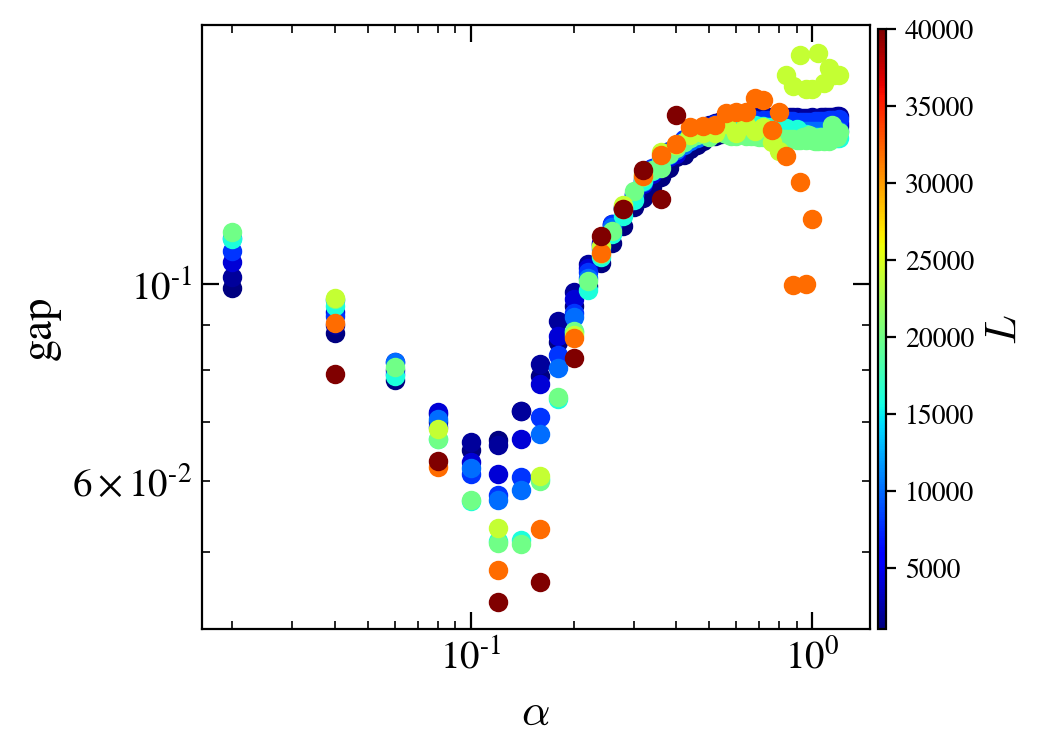

In [17]:

markers = itertools.cycle(markers_ls)

J=1

alfa=0.6
h=0
w=1
zeta=0.1

N=1000
gamma=1
ini_ave=0

L = 4000

alfa_vals = np.arange(0.02, 1.21, 0.02)
print(alfa_vals)
    
window = 6
projected = 1

energy_density = None
gap_ratio_density = []

sizes = np.array( [1000, 2000, 4000, 8000, 10000, 16000, 20000, 24000, 32000, 40000] )

# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm= matplotlib.colors.Normalize(vmin=min(sizes), vmax=max(sizes) ))
s_m.set_array([])

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,4), dpi = 200, sharex = True)


for L in sizes:
    N = 1000#L//4
    col = s_m.to_rgba(L)
    E0 = np.zeros(alfa_vals.shape); E0.fill(np.nan)
    for ii, alfa in enumerate(alfa_vals):
        name = base_dir + 'DIAGONALIZATION/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
        if exists(name):
            with h5py.File(name, "r") as file:
                E0[ii] = np.mean(np.array(file.get('low_energies'))[:,1] - np.array(file.get('low_energies'))[:,0] )
                # E0[ii] = np.mean(np.array(file.get('dE'))) / np.log(L)**3# - 2.5
                
        else:
            print(name)
    axis.scatter(alfa_vals, E0, color=col)
fig_help.set_plot_elements(axis, ylabel=r"gap", xlabel=r"$\alpha$", font_size=14, set_legend=False, yscale='log', xscale='log')

fig.subplots_adjust(right=0.96)
cbar_ax = fig.add_axes([0.97, 0.125, 0.01, 0.75])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$L$", fontsize=16)

fig.subplots_adjust(wspace = 0.14, hspace=0.04)
# fig.savefig("plots_AGP/FigS2.pdf", bbox_inches = 'tight', pad_inches=0.02)

[0.02 0.04 0.06 0.08 0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26 0.28
 0.3  0.32 0.34 0.36 0.38 0.4  0.42 0.44 0.46 0.48 0.5  0.52 0.54 0.56
 0.58 0.6  0.62 0.64 0.66 0.68 0.7  0.72 0.74 0.76 0.78 0.8 ]
../results/DIAGONALIZATION/_L=24000,N=1000,J=1,g=1,zeta=0.1,alfa=0.02,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=24000,N=1000,J=1,g=1,zeta=0.1,alfa=0.06,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=24000,N=1000,J=1,g=1,zeta=0.1,alfa=0.1,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=24000,N=1000,J=1,g=1,zeta=0.1,alfa=0.14,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=24000,N=1000,J=1,g=1,zeta=0.1,alfa=0.18,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=24000,N=1000,J=1,g=1,zeta=0.1,alfa=0.22,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=24000,N=1000,J=1,g=1,zeta=0.1,alfa=0.26,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=24000,N=1000,J=1,g=1,zeta=0.1,alfa=0.3,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=24000,N=1000,J=1,g=1,zeta=0.1,alfa=0.34,h=0,w=1.hdf5
../results/DIAGONALIZATION/_L=24000,N=1000,J=1,g=1,

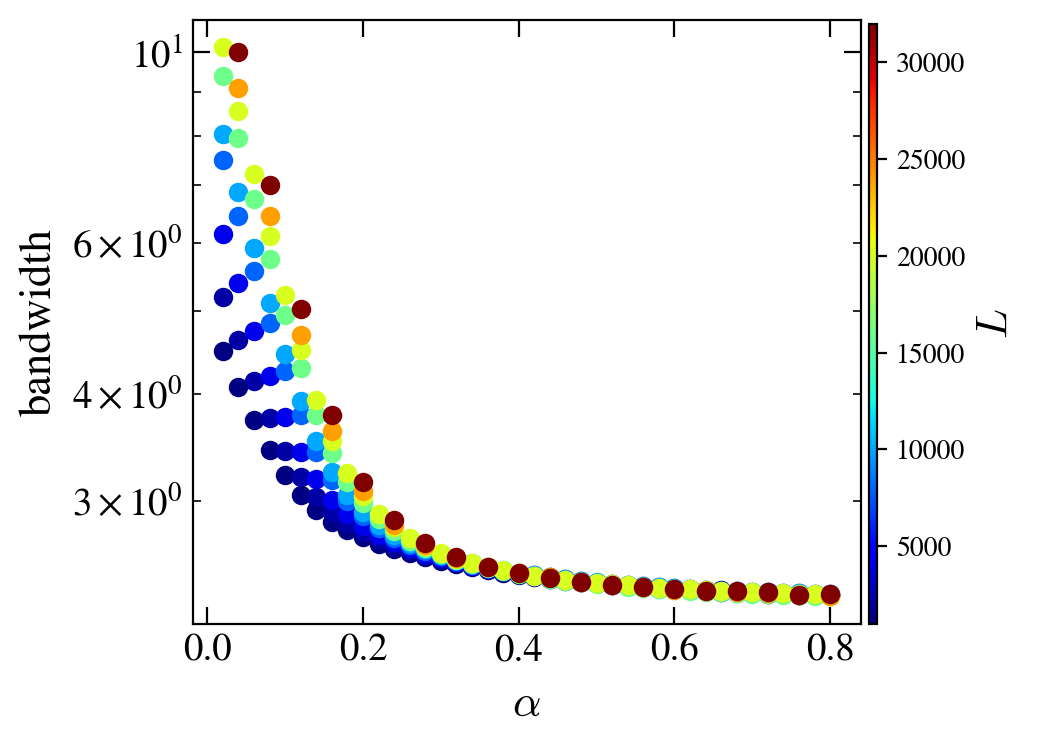

In [26]:

markers = itertools.cycle(markers_ls)

J=1

alfa=0.6
h=0
w=1
zeta=0.1

N=1000
gamma=1
ini_ave=0

L = 1000

alfa_vals = np.arange(0.02, 0.81, 0.02)
print(alfa_vals)
    
window = 6
projected = 1

energy_density = None
gap_ratio_density = []

sizes = np.array( [1000, 2000, 4000, 8000, 10000, 16000, 20000, 24000, 32000] )

# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm= matplotlib.colors.Normalize(vmin=min(sizes), vmax=max(sizes) ))
s_m.set_array([])

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,4), dpi = 200, sharex = True)


for L in sizes:
    # N = L//4
    col = s_m.to_rgba(L)
    E0 = np.zeros(alfa_vals.shape); E0.fill(np.nan)
    for ii, alfa in enumerate(alfa_vals):
        name = base_dir + 'DIAGONALIZATION/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
        if exists(name):
            with h5py.File(name, "r") as file:
                # E0[ii] = np.mean(np.array(file.get('low_energies'))[:,1] - np.array(file.get('low_energies'))[:,0] )
                E0[ii] = np.mean(np.array(file.get('dE')))
                
        else:
            print(name)
    axis.scatter(alfa_vals, E0, color=col)
fig_help.set_plot_elements(axis, ylabel=r"bandwidth", xlabel=r"$\alpha$", font_size=14, set_legend=False, yscale='log')

fig.subplots_adjust(right=0.96)
cbar_ax = fig.add_axes([0.97, 0.125, 0.01, 0.75])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$L$", fontsize=16)

fig.subplots_adjust(wspace = 0.14, hspace=0.04)
# fig.savefig("plots_AGP/FigS2.pdf", bbox_inches = 'tight', pad_inches=0.02)